# Задача 10. Экспериментальное исследование алгоритмов решения задачи достижимости с КС ограничениями

### Постановка задачи:
Задача посвящена анализу производительности различных алгоритмов решения задачи достижимости между всеми парами вершин с контекстно-свободными ограничениями: **алгоритма Хеллингса, матричного алгоритма, тензорного алгоритма и алгоритма на основе GLL**.

### Ход решения:
Для решения поставленной задачи необходимо ответить на следующие вопросы:
1. Какой из трёх указанных алгоритмов обладает лучшей производительностью?
2. Имеет ли смысл для решения задачи достижимости с регулярными ограничениями использовать алгоритмы для КС ограничений (ведь регулярные — частный случай КС) или всё же лучше использовать специализированные алгоритмы для регулярных ограничений?
3. Как влияет грамматика на производительность тензорного алгоритма и алгоритма на основе GLL? Если зафиксировать язык, то как свойства грамматики (размер, (не)однозначность) влияют на производительность.

### Описание исследуемых решений
В работе сравнивались следующие алгоритмы:
1. Алгоритм Хеллингса.

    *Перед началом работы алгоритма, грамматика переводится в ОНФХ*. Отдельно храним не рассмотренные ребра. Каждое нерассмотренное ребро проверяем на порождаемость со смежными; в случае успеха, сохраняем данную пару ребер вместе с соответствующим нетерминалом.
2. Матричный алгоритм.

    *Перед началом работы алгоритма, грамматика переводится в ОНФХ*. Далее строится матрица смежности графа, элементами которой являются множества нетерминалов из которых выводимы пути между соответствующими вершинами. Далее возводим матрицу в квадрат и прибавляем её к изначальной. Производим эту операци до тех пор, пока она не перестанет меняться. На этом этапе получили множество всех путей. Далее можем найти множество путей из стартовых вершин в финальные.
3. Тензорный алгоритм.

    *Перед началом работы алгоритма, по грамматике строится RSM*. Далее строится пересечение RSM и графа с использованием тензорного произведения. После строится транзитивное замыкание получившегося пересечения, ребра которого добавляются в графах. Процесс повторяется до тех пор, пока мы не перестанем находить новые ребра.
4. GLL (Generalized LL).

    *Перед началом работы алгоритма, по грамматике строится RSM*. Алгоритм анализирует граф, начиная с начальных состояний автомата, и обрабатывает терминальные и нетерминальные переходы для нахождения достижимых пар узлов. В процессе используется графо-структурированный стек (GSS), который строится рекурсивно, с учетом всех возможных переходов, пока не будут найдены все пары узлов, которые соответствуют стартовым и конечным условиям задачи.

### Описание набора данных для экспериментов

#### Набор данных для эксперимента:
Для эксперимента был выбран набор [CFPQ_Data](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/index.html), предназначенный для оценки алгоритмов для обработки контекстно-свободного запросов.

Графы в наборе делятся на RDF-графы и графы для языка C.

Были взяты следующие RDF-графы:
- [skos](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/skos.html#skos) 144 nodes 252 edges
- [travel](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/travel.html#travel) 131 nodes 277 edges
- [wine](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/wine.html#wine) 733 nodes 1839 edges

Были взяты следующие графы языка C:
- [wc](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/wc.html#wc) 332 nodes 269 edges 
- [bzip](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/bzip.html#bzip) 632 nodes 556 edges
- [pr](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/pr.html#pr) 815 nodes 692 edges

#### Запросы и регулярные выражения:
Для каждого графа были выбраны следующие КС-запросы:

#### Для графов RDF

1. $S -> subClassOf_r S subClassOf | subClassOf_r subClassOf | type_r S type | type_r type$
2. $S -> subClassOf_r S subClassOf | subClassOf_r subClassOf$
3. $S -> type_r S type | type_r type$

#### Для графов языка C

- $S -> d_r V d$
- $V -> V_1 V_2 V_3$
- $V_1 -> epsilon$
- $V_1 -> V_2 a_r V_1$
- $V_2 -> epsilon$
- $V_2 -> S$
- $V_3 -> epsilon$
- $V_3 -> a V_2 V_3$

#### Для ответа на второй вопрос были выбраны следующие регулярные запросы:

1. $(l_1 l_2)+$
2. $(l_3 l_4)*$
3. $(l_1 | l_2 | l_3)+$
4. $(l_1? l_2 l_3)$


## Описание эксперимента
### Характеристика вычислительной машины:

- OC MacOS Sequoia 15.6.1
- Процессор Apple M2 (8 ядер)
- Кэш
    - L1-кэш - 256 KB, 
    - L2-кэш - 20 MB
    - L3-кэш - 8 MБ

- 8GB RAM
- 256GB SSD

## Проведение эксперимента

1) Для ответа на первый вопрос для графа из каждой группы запускаем все 4 алгоритма на каждом из выбранных запросов. Количество запусков
 20, из которых бралось среднее время работы и стандартное отклонение.

2) Для ответа на второй вопрос, для каждого графа два выбранных алгоритма запускаются на каждом регулярном выражении. Алгоритмы также запускаются 20 раз, чтобы получить среднее время выполнения для каждого количества стартовых вершин.

3) Для ответа на третий вопрос, выбранные грамматики расширяются и преобразуются в неоднозначные, далее для графа из каждой группы запускаем все 4 алгоритма на каждом из выбранных запросов. Количество запусков 20, из которых бралось среднее время работы и стандартное отклонение, после чего результат сравнивается с результатом, полученным для первого вопроса.



In [ ]:
%matplotlib inline

import pandas as pd
import logging
import matplotlib.pyplot as plt
import time
import cfpq_data
import gc
import networkx as nx
import warnings
import numpy as np

from collections import Counter
from scipy.sparse import SparseEfficiencyWarning
from pyformlang.cfg import CFG

from project.task1_graph import get_graph
from project.task3 import tensor_based_rpq
from project.task6_cfpq import hellings_based_cfpq
from project.task7_matrix_cfpq import matrix_based_cfpq
from project.task8_tensors import tensor_based_cfpq, cfg_to_rsm
from project.task9_gll import gll_based_cfpq

log = logging.getLogger("cfpq_bench")
log.setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)
cfpq_data.logging.disable()

ENABLED_ALGOS = {"hellings_based", "matrix_based", "tensor_based", "gll_based"}

#### Инициализация грамматик и регулярных запросов, и всего прочего, что пригодится в эксперименте:


In [54]:
GRAMMAR_RDF = [
    CFG.from_text(
        "S -> subClassOf_r S subClassOf | subClassOf_r subClassOf | type_r S type | type_r type"
    ),
    CFG.from_text("S -> subClassOf_r S subClassOf | subClassOf_r subClassOf"),
    CFG.from_text("S -> type_r S type | type_r type"),
]

GRAMMAR_C = [
    CFG.from_text("""
    S -> d_r V d
    V -> V1 V2 V3
    V1 -> epsilon
    V1 -> V2 a_r V1
    V2 -> epsilon
    V2 -> S
    V3 -> epsilon
    V3 -> a V2 V3
""")
]

GRAMMAR_RDF_MUT = [
    CFG.from_text(
        "S -> subClassOf_r S subClassOf | subClassOf_r subClassOf | type_r S type | type_r type | subClassOf_r S subClassOf subClassOf | type_r S type subClassOf"
    ),
    CFG.from_text(
        "S -> subClassOf_r S subClassOf | subClassOf_r subClassOf | type_r S type | type_r type | subClassOf_r S subClassOf subClassOf | type_r S type subClassOf | type_r subClassOf subClassOf_r type"
    ),
    CFG.from_text(
        "S -> subClassOf_r S subClassOf | subClassOf_r subClassOf | type_r S type | type_r type | type_r type subClassOf | subClassOf_r S type"
    ),
]

GRAMMAR_C_MUT = [
    CFG.from_text("""
    S -> d_r V d | V d | d_r V d V
    V -> V1 V2 V3 | V1 V2 V3 V
    V1 -> epsilon | V2 a_r V1 | a_r V1
    V2 -> epsilon | S | V3
    V3 -> epsilon | a V2 V3 | V1 a_r V3
""")
]

In [ ]:
def _popular_labels_from_graph(g: nx.Graph, k: int = 4) -> list[str]:
    labels = [edata["label"] for _, _, edata in g.edges(data=True)]
    most = [lbl for lbl, _ in Counter(labels).most_common(k)]
    while len(most) < 4:
        most.append(most[-1] if most else "a")
    return most[:4]


def _synthetic_langs_from_labels(labels: list[str]):
    a, b, c, d = labels[:4]
    cfg1 = CFG.from_text(f"S -> {a} B\nB -> {b} S | {b}")
    re1 = f"({a} {b})+"
    cfg2 = CFG.from_text(f"S -> {c} T\nT -> {d} T | epsilon")
    re2 = f"{c} {d}*"
    cfg3 = CFG.from_text(f"S -> {a} S | {b} S | {c} S | {a} | {b} | {c}")
    re3 = f"({a}|{b}|{c})+"
    cfg4 = CFG.from_text(f"S -> {b} | {a} {b} | {b} {c} | {a} {b} {c}")
    re4 = f"{a}? {b} {c}?"
    return [(re1, cfg1), (re2, cfg2), (re3, cfg3), (re4, cfg4)]

In [ ]:
def _safe_add_reverse_edges(g: nx.Graph):
    if not getattr(g, "_rev_added", False):
        cfpq_data.graphs.add_reverse_edges(g)
        g._rev_added = True


def _mk_graph_pool(names):
    pool = {}
    for n in names:
        g = get_graph(n)
        _safe_add_reverse_edges(g)
        pool[n] = g
    return pool


POOL = _mk_graph_pool(["skos", "travel", "wine", "wc", "bzip", "pr"])


def G(name: str) -> nx.Graph:
    return POOL[name]

In [ ]:
def _run_safely(fn):
    t0 = time.perf_counter()
    try:
        fn()
        return time.perf_counter() - t0
    except Exception as ex:
        log.error(f"algorithm failed: {ex}")
        return float("nan")
    finally:
        gc.collect()


def eval_case(cfg: CFG, g: nx.Graph, start=None, finish=None) -> dict:
    if start is None:
        start = {}
    if finish is None:
        finish = {}

    out = {}
    out["hellings_based"] = (
        _run_safely(lambda: hellings_based_cfpq(cfg, g, start, finish))
        if "hellings_based" in ENABLED_ALGOS
        else float("nan")
    )
    out["matrix_based"] = (
        _run_safely(lambda: matrix_based_cfpq(cfg, g, start, finish))
        if "matrix_based" in ENABLED_ALGOS
        else float("nan")
    )

    rsm = None
    if ("tensor_based" in ENABLED_ALGOS) or ("gll_based" in ENABLED_ALGOS):
        rsm = cfg_to_rsm(cfg)

    out["tensor_based"] = (
        _run_safely(lambda: tensor_based_cfpq(rsm, g, start, finish))
        if "tensor_based" in ENABLED_ALGOS
        else float("nan")
    )
    out["gll_based"] = (
        _run_safely(lambda: gll_based_cfpq(rsm, g, start, finish))
        if "gll_based" in ENABLED_ALGOS
        else float("nan")
    )

    return out


def _aggregate(rows: list[dict]) -> pd.DataFrame:
    raw = pd.DataFrame(rows)
    grouped = (
        raw.groupby(["Combination", "Algorithm"])["Time"]
        .agg(["mean", "std"])
        .reset_index()
    )
    grouped.rename(
        columns={"mean": "Average Time (seconds)", "std": "Std Dev (seconds)"},
        inplace=True,
    )
    return grouped


def plot_grouped_bars(
    df: pd.DataFrame, title: str, save_as: str | None = None, logy: bool = True
):
    order_alg = ["hellings_based", "matrix_based", "tensor_based", "gll_based"]

    df = df.copy()
    df["Algorithm"] = pd.Categorical(df["Algorithm"], order_alg, ordered=True)

    pivot_avg = df.pivot(
        index="Combination", columns="Algorithm", values="Average Time (seconds)"
    )
    pivot_std = df.pivot(
        index="Combination", columns="Algorithm", values="Std Dev (seconds)"
    )

    x = np.arange(len(pivot_avg.index))
    width = 0.18

    plt.figure(figsize=(max(10, 1.2 * len(x)), 6))
    ax = plt.gca()
    for i, alg in enumerate(order_alg):
        if alg not in pivot_avg.columns:
            continue
        means = pivot_avg[alg].values
        errs = pivot_std[alg].values
        ax.bar(x + (i - 1.5) * width, means, width, yerr=errs, capsize=4, label=alg)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot_avg.index, rotation=35, ha="right")
    ax.set_ylabel("Time (seconds)")
    ax.set_title(title)
    if logy:
        ax.set_yscale("log")
    ax.legend(title="Algorithms", ncol=2)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches="tight")
    plt.show()


def compare_rpq_vs_cfpq(regex_text: str, cfg: CFG, g: nx.Graph) -> dict:
    res = {}
    res["tensor_based"] = _run_safely(lambda: tensor_based_rpq(regex_text, g, {}, {}))
    res["gll_based"] = _run_safely(lambda: gll_based_cfpq(cfg_to_rsm(cfg), g, {}, {}))
    return res


def summarize(df: pd.DataFrame, top_k: int = 3) -> list[str]:
    msgs = []

    best_lines = []
    for comb, sub in df.groupby("Combination"):
        sub = sub.dropna(subset=["Average Time (seconds)"])
        if sub.empty:
            continue
        best = sub.loc[sub["Average Time (seconds)"].idxmin()]
        best_lines.append(
            f"• {comb}: быстрее всего — {best['Algorithm']} (≈ {best['Average Time (seconds)']:.3g} s)"
        )
    if best_lines:
        msgs.append("Лучшие результаты по комбинациям:\n" + "\n".join(best_lines))

    med = df.groupby("Algorithm")["Average Time (seconds)"].median().sort_values()
    head = med.head(min(top_k, len(med)))
    msgs.append(
        "Сводно по алгоритмам (медиана времени, меньше — лучше): "
        + ", ".join([f"{alg}: {val:.3g}s" for alg, val in head.items()])
    )

    close_lines = []
    for comb, sub in df.groupby("Combination"):
        if len(sub) < 2:
            continue
        s = sub.sort_values("Average Time (seconds)")
        first, second = s.iloc[0], s.iloc[1]
        avg_std = np.nanmean([first["Std Dev (seconds)"], second["Std Dev (seconds)"]])
        if np.isfinite(avg_std) and (
            second["Average Time (seconds)"] - first["Average Time (seconds)"]
            <= avg_std
        ):
            close_lines.append(
                f"• {comb}: {first['Algorithm']} и {second['Algorithm']} показывают схожее время."
            )
    if close_lines:
        msgs.append("Где результаты примерно равны:\n" + "\n".join(close_lines))

    return msgs

### Реализация экспериментов

In [ ]:
def exp_baseline(n_runs: int = 20) -> pd.DataFrame:
    combos = []
    for i, cfg in enumerate(GRAMMAR_RDF):
        combos += [
            (cfg, G("skos"), f"skos rdf_cfg_{i}"),
            (cfg, G("travel"), f"travel rdf_cfg_{i}"),
            (cfg, G("wine"), f"wine rdf_cfg_{i}"),
        ]

    combos += [
        (GRAMMAR_C[0], G("wc"), "wc c_cfg_0"),
        (GRAMMAR_C[0], G("bzip"), "bzip c_cfg_0"),
        (GRAMMAR_C[0], G("pr"), "pr c_cfg_0"),
    ]

    rows = []
    for cfg, g, label in combos:
        for _ in range(n_runs):
            times = eval_case(cfg, g)
            for alg, t in times.items():
                rows.append({"Combination": label, "Algorithm": alg, "Time": t})

    df = _aggregate(rows)
    plot_grouped_bars(
        df,
        "Baseline: время алгоритмов по CFG/графам",
        save_as="baseline_benchmark.png",
        logy=True,
    )
    return df


def exp_rpq_vs_cfpq(n_runs: int = 20) -> pd.DataFrame:
    targets = ["skos", "travel", "wine", "wc", "bzip", "pr"]
    rows = []
    for gname in targets:
        g = G(gname)
        labels = _popular_labels_from_graph(g, 4)
        patterns = _synthetic_langs_from_labels(labels)
        for idx, (re_text, cfg) in enumerate(patterns):
            for _ in range(n_runs):
                r = compare_rpq_vs_cfpq(re_text, cfg, g)
                for alg, t in r.items():
                    rows.append(
                        {
                            "Combination": f"{gname}-reg_{idx}",
                            "Algorithm": alg,
                            "Time": t,
                        }
                    )

    df = _aggregate(rows)
    plot_grouped_bars(
        df,
        "RPQ (tensor) vs CFPQ (GLL) — сравнение",
        save_as="rpq_vs_cfpq.png",
        logy=True,
    )
    return df


def exp_altered(n_runs: int = 20) -> pd.DataFrame:
    combos = []
    for i, (orig, mut) in enumerate(zip(GRAMMAR_RDF, GRAMMAR_RDF_MUT)):
        combos += [
            (orig, G("skos"), f"skos rdf_cfg_{i}"),
            (mut, G("skos"), f"skos rdf_cfg_{i}_altered"),
            (orig, G("travel"), f"travel rdf_cfg_{i}"),
            (mut, G("travel"), f"travel rdf_cfg_{i}_altered"),
            (orig, G("wine"), f"wine rdf_cfg_{i}"),
            (mut, G("wine"), f"wine rdf_cfg_{i}_altered"),
        ]

    combos += [
        (GRAMMAR_C[0], G("wc"), "wc c_cfg_0"),
        (GRAMMAR_C_MUT[0], G("wc"), "wc c_cfg_0_altered"),
        (GRAMMAR_C[0], G("bzip"), "bzip c_cfg_0"),
        (GRAMMAR_C_MUT[0], G("bzip"), "bzip c_cfg_0_altered"),
        (GRAMMAR_C[0], G("pr"), "pr c_cfg_0"),
        (GRAMMAR_C_MUT[0], G("pr"), "pr c_cfg_0_altered"),
    ]

    rows = []
    for cfg, g, label in combos:
        for _ in range(n_runs):
            times = eval_case(cfg, g)
            for alg, t in times.items():
                rows.append({"Combination": label, "Algorithm": alg, "Time": t})

    df = _aggregate(rows)
    plot_grouped_bars(
        df,
        "Altered grammars: сравнение времени",
        save_as="altered_grammars.png",
        logy=True,
    )
    return df

In [ ]:
REPETITIONS = 20

### 1. Какой из трёх указанных алгоритмов обладает лучшей производительностью?

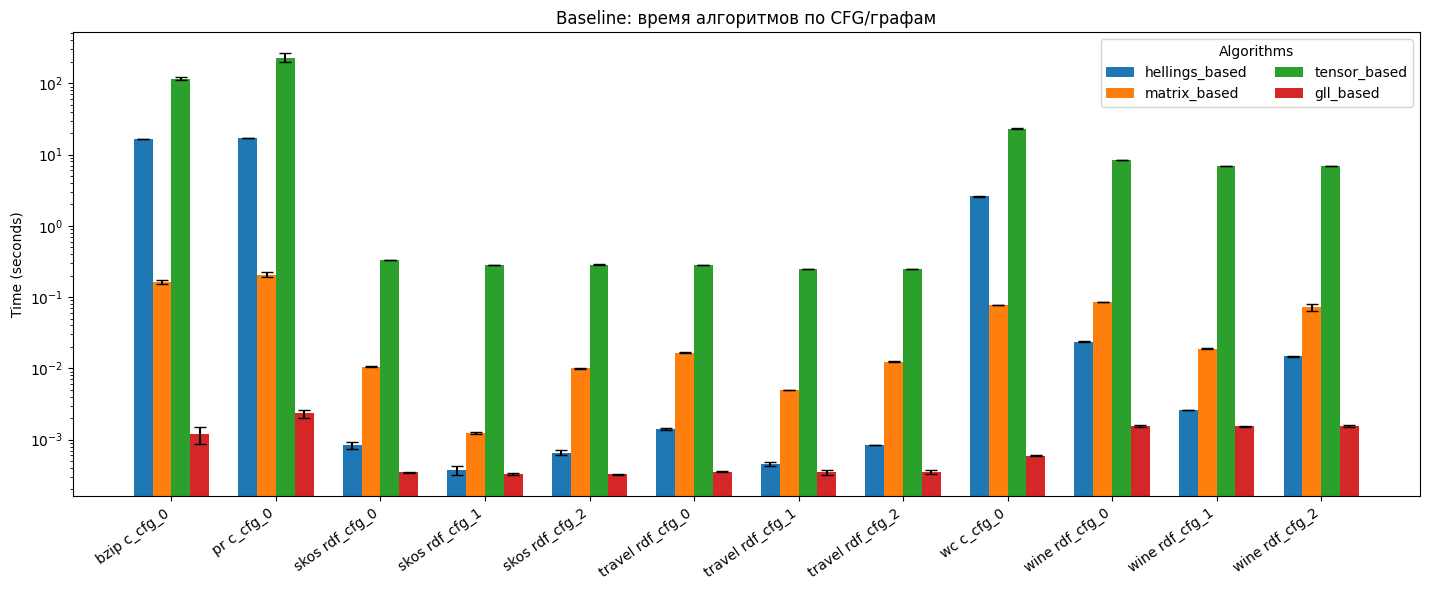

Лучшие результаты по комбинациям:
• bzip c_cfg_0: быстрее всего — gll_based (≈ 0.00118 s)
• pr c_cfg_0: быстрее всего — gll_based (≈ 0.00233 s)
• skos rdf_cfg_0: быстрее всего — gll_based (≈ 0.000347 s)
• skos rdf_cfg_1: быстрее всего — gll_based (≈ 0.000331 s)
• skos rdf_cfg_2: быстрее всего — gll_based (≈ 0.000324 s)
• travel rdf_cfg_0: быстрее всего — gll_based (≈ 0.000355 s)
• travel rdf_cfg_1: быстрее всего — gll_based (≈ 0.000346 s)
• travel rdf_cfg_2: быстрее всего — gll_based (≈ 0.000351 s)
• wc c_cfg_0: быстрее всего — gll_based (≈ 0.000599 s)
• wine rdf_cfg_0: быстрее всего — gll_based (≈ 0.00154 s)
• wine rdf_cfg_1: быстрее всего — gll_based (≈ 0.00154 s)
• wine rdf_cfg_2: быстрее всего — gll_based (≈ 0.00155 s)
Сводно по алгоритмам (медиана времени, меньше — лучше): gll_based: 0.000477s, hellings_based: 0.00201s, matrix_based: 0.0178s

=== Baseline table ===


,Combination,Algorithm,Average Time (seconds),Std Dev (seconds)
0,bzip c_cfg_0,gll_based,0.001185,0.000302
1,bzip c_cfg_0,hellings_based,16.568438,0.074811
2,bzip c_cfg_0,matrix_based,0.163206,0.009228
3,bzip c_cfg_0,tensor_based,115.433523,5.610507
4,pr c_cfg_0,gll_based,0.002330,0.000295
5,pr c_cfg_0,hellings_based,17.104581,0.040978
6,pr c_cfg_0,matrix_based,0.205391,0.016119
7,pr c_cfg_0,tensor_based,228.817006,33.139502
8,skos rdf_cfg_0,gll_based,0.000347,0.000003
9,skos rdf_cfg_0,hellings_based,0.000828,0.000088


In [34]:
df_base = exp_baseline(n_runs=REPETITIONS)
for line in summarize(df_base):
    print(line)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("\n=== Baseline table ===")
    display(df_base.sort_values(["Combination", "Algorithm"]))

+ Графы travel и skos являются самыми маленькими графами по количеству вершин и ребер в наборе. Можно заметить интересное наблюдение, что алгоритм Хеллингса здесь может работать почти наравне по скорости с GLL. Однако с увеличенем размера графа время выполнения Хеллинга начинает замедляться ближе по скорости к тензорному алгоритму, который везде показал себя хуже всех.

+ Матричный подход и GLL работают заметно быстрее других, но GLL выигрывает. Такие результаты неожиданные, но объяснимы.

Дело в том, что в алгоритме Хеллинга и в матричном алгоритме были выбраны не самые удачные по производительности реализации. У них обоих похожая структура, разница только в данных, с которыми работают алгоритмы. Алгоритм Хеллингса реализует правила грамматики через тройки (u, N, v), а матричный через булевы матрицы для каждого нетерминала. 

Ход обоих алгоритмов примерно следующий: цикл выполняется пока добавляются новые пары вершин.
В худшем случае — пока матрицы перестанут изменяться, что может работать очень долго.

Матричный алгоритм

```
while added:
    added = False

    for prod in cfg.productions:
        ...
```
Алгоритм Хеллингса
```
while added:
    added = False

    for (u1, var1, u2), (u1_, var2, u2_) in itertools.product(cfpq_results)
        ...
```

В алгоритме Хеллингса здесь вообще перебираем $k^2$ вариантов троек (При каждом добавлении новых троек пересчитывается всё произведение троек). При росте графа и грамматики k может достигать десятков или сотен тысяч. Тогда $k^2$ будет уже сильно хуже вычислительно

### 2. Имеет ли смысл для решения задачи достижимости с регулярными ограничениями использовать алгоритмы для КС ограничений?

В качестве CFPQ алгоритма был выбран GLL как наиболее производительный по результатам ответа на предыдущий вопрос.

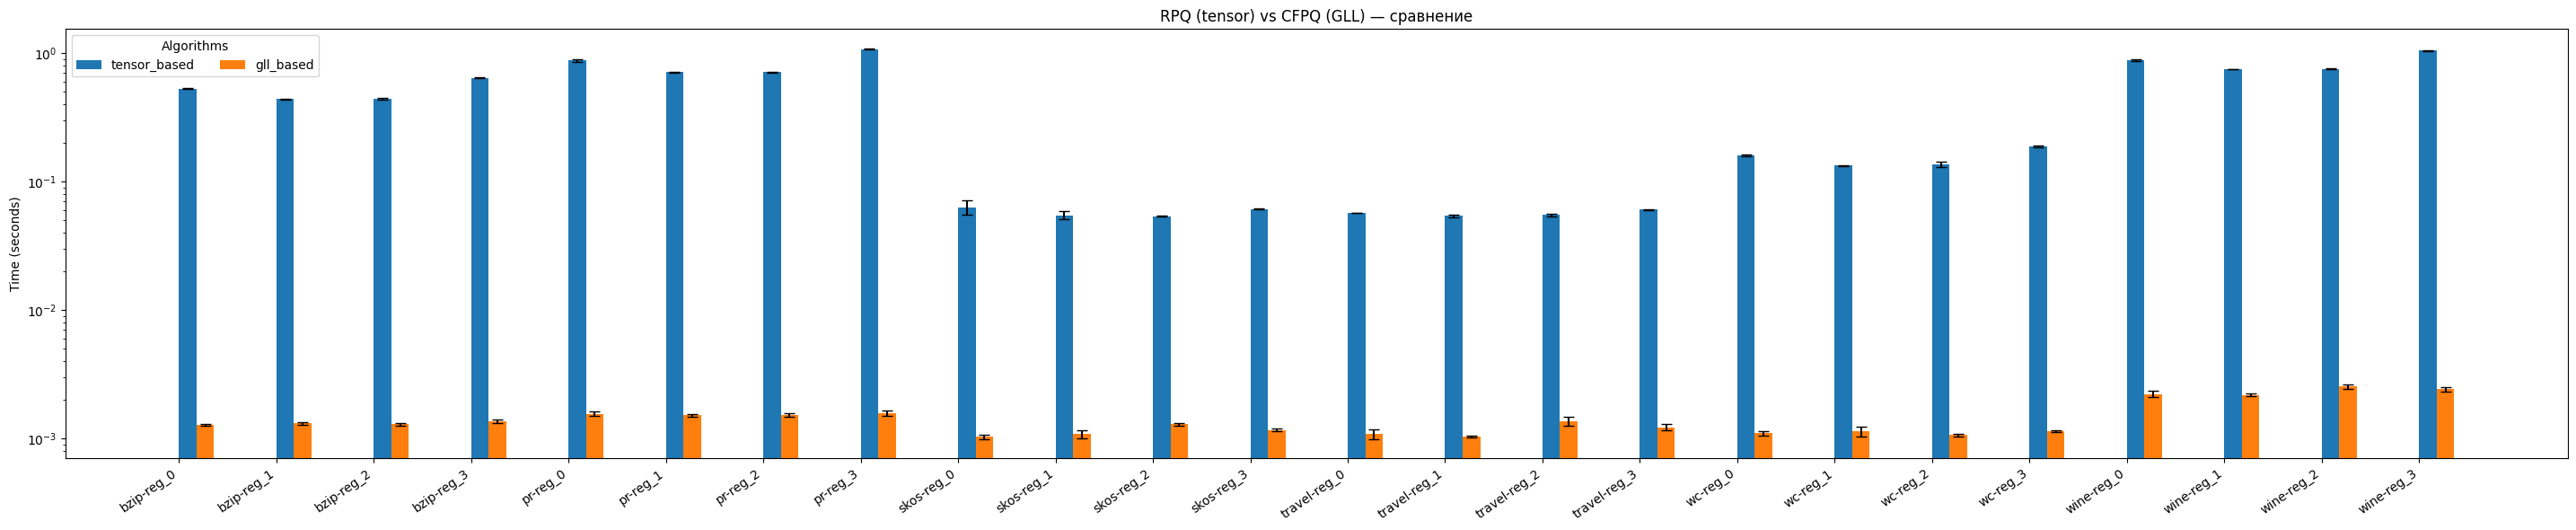

Лучшие результаты по комбинациям:
• bzip-reg_0: быстрее всего — gll_based (≈ 0.00128 s)
• bzip-reg_1: быстрее всего — gll_based (≈ 0.00131 s)
• bzip-reg_2: быстрее всего — gll_based (≈ 0.00129 s)
• bzip-reg_3: быстрее всего — gll_based (≈ 0.00137 s)
• pr-reg_0: быстрее всего — gll_based (≈ 0.00156 s)
• pr-reg_1: быстрее всего — gll_based (≈ 0.00152 s)
• pr-reg_2: быстрее всего — gll_based (≈ 0.00154 s)
• pr-reg_3: быстрее всего — gll_based (≈ 0.00159 s)
• skos-reg_0: быстрее всего — gll_based (≈ 0.00103 s)
• skos-reg_1: быстрее всего — gll_based (≈ 0.00108 s)
• skos-reg_2: быстрее всего — gll_based (≈ 0.00129 s)
• skos-reg_3: быстрее всего — gll_based (≈ 0.00117 s)
• travel-reg_0: быстрее всего — gll_based (≈ 0.00108 s)
• travel-reg_1: быстрее всего — gll_based (≈ 0.00104 s)
• travel-reg_2: быстрее всего — gll_based (≈ 0.00137 s)
• travel-reg_3: быстрее всего — gll_based (≈ 0.00122 s)
• wc-reg_0: быстрее всего — gll_based (≈ 0.0011 s)
• wc-reg_1: быстрее всего — gll_based (≈ 0.00114 s)

,Combination,Algorithm,Average Time (seconds),Std Dev (seconds)
0,bzip-reg_0,gll_based,0.001282,0.000028
1,bzip-reg_0,tensor_based,0.528499,0.004952
2,bzip-reg_1,gll_based,0.001312,0.000037
3,bzip-reg_1,tensor_based,0.437666,0.003716
4,bzip-reg_2,gll_based,0.001292,0.000029
5,bzip-reg_2,tensor_based,0.439044,0.004878
6,bzip-reg_3,gll_based,0.001368,0.000042
7,bzip-reg_3,tensor_based,0.639253,0.004806
8,pr-reg_0,gll_based,0.001561,0.000068
9,pr-reg_0,tensor_based,0.872750,0.021996


In [58]:
df_rpq = exp_rpq_vs_cfpq(n_runs=5)
for line in summarize(df_rpq):
    print(line)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("\n=== RPQ vs CFPQ table ===")
    display(df_rpq.sort_values(["Combination", "Algorithm"]))

Как видно из диаграмы, алгоритм GLL для КС-запросов оказался более производительным нежели специализированный тензорный алгоритм для регулярных запросов. 

Итог: нет смысла использовать специализированные алгоритмы для регулярных запросов, когда есть более общие и производительные алгоритмы для КС-запросов

### 3. Как влияет грамматика на производительность тензорного алгоритма и алгоритма на основе GLL? Если зафиксировать язык, то как свойства грамматики (размер, (не)однозначность) влияют на производительность?


Здесь график получился немного избыточным. Алгоритм Хеллингса и матричный алгоритм в этом вопросе не учитываются.

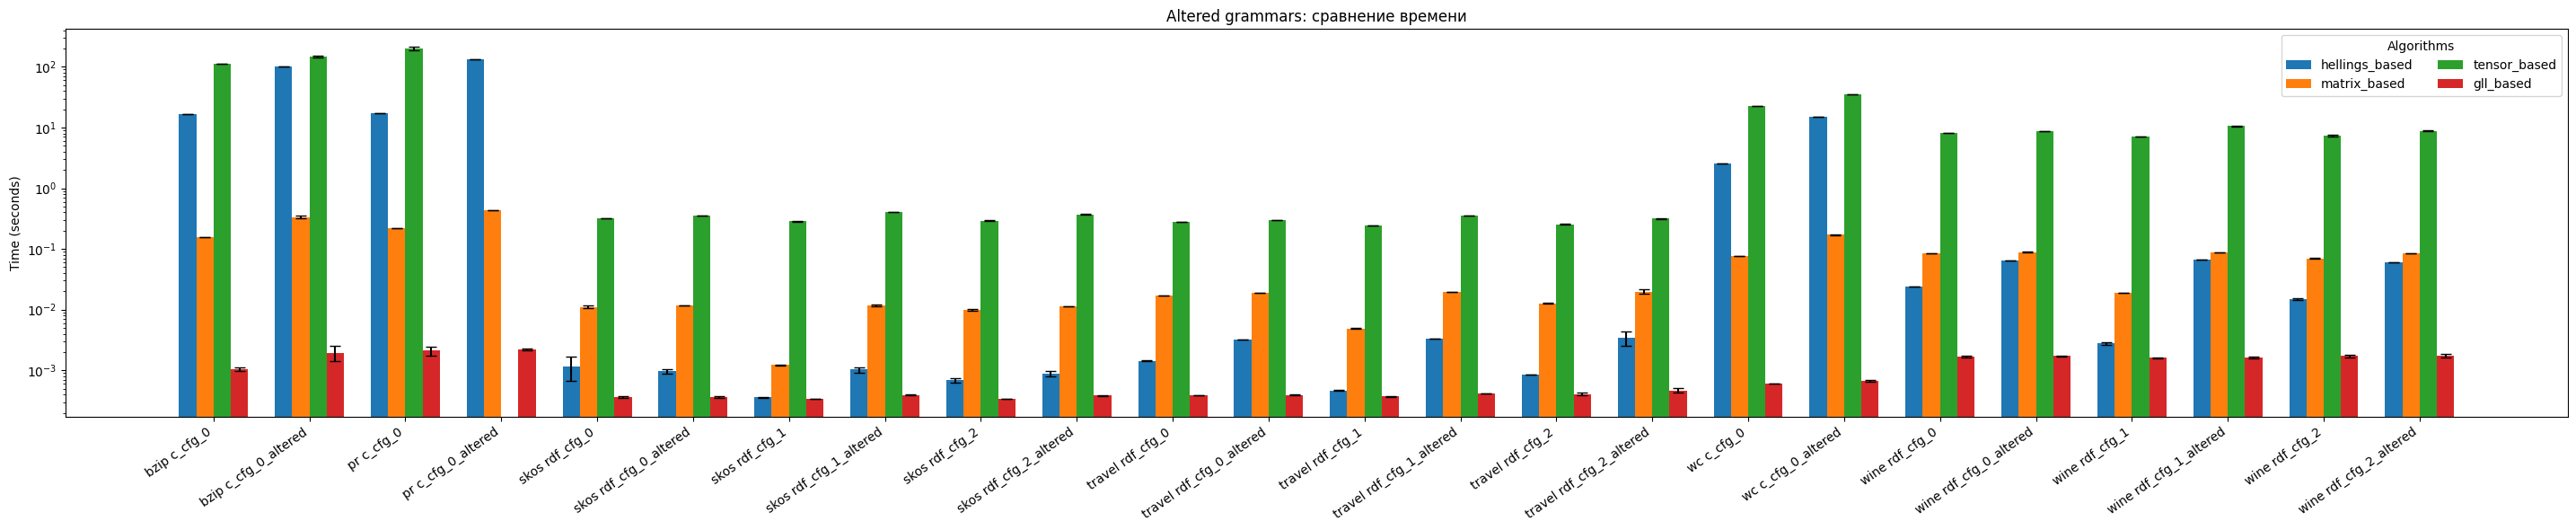

Лучшие результаты по комбинациям:
• bzip c_cfg_0: быстрее всего — gll_based (≈ 0.00105 s)
• bzip c_cfg_0_altered: быстрее всего — gll_based (≈ 0.00195 s)
• pr c_cfg_0: быстрее всего — gll_based (≈ 0.00212 s)
• pr c_cfg_0_altered: быстрее всего — gll_based (≈ 0.00222 s)
• skos rdf_cfg_0: быстрее всего — gll_based (≈ 0.000363 s)
• skos rdf_cfg_0_altered: быстрее всего — gll_based (≈ 0.000362 s)
• skos rdf_cfg_1: быстрее всего — gll_based (≈ 0.000336 s)
• skos rdf_cfg_1_altered: быстрее всего — gll_based (≈ 0.000392 s)
• skos rdf_cfg_2: быстрее всего — gll_based (≈ 0.000339 s)
• skos rdf_cfg_2_altered: быстрее всего — gll_based (≈ 0.000385 s)
• travel rdf_cfg_0: быстрее всего — gll_based (≈ 0.000393 s)
• travel rdf_cfg_0_altered: быстрее всего — gll_based (≈ 0.000395 s)
• travel rdf_cfg_1: быстрее всего — gll_based (≈ 0.000374 s)
• travel rdf_cfg_1_altered: быстрее всего — gll_based (≈ 0.000415 s)
• travel rdf_cfg_2: быстрее всего — gll_based (≈ 0.000408 s)
• travel rdf_cfg_2_altered: быс

,Combination,Algorithm,Average Time (seconds),Std Dev (seconds)
0,bzip c_cfg_0,gll_based,0.001046,6.979144e-05
1,bzip c_cfg_0,hellings_based,16.658009,9.732688e-03
2,bzip c_cfg_0,matrix_based,0.157747,5.865451e-04
3,bzip c_cfg_0,tensor_based,112.128105,6.906381e-01
4,bzip c_cfg_0_altered,gll_based,0.001950,5.462400e-04
5,bzip c_cfg_0_altered,hellings_based,100.414677,3.802248e-02
6,bzip c_cfg_0_altered,matrix_based,0.336461,1.296417e-02
7,bzip c_cfg_0_altered,tensor_based,148.124730,6.830179e+00
8,pr c_cfg_0,gll_based,0.002116,3.698876e-04
9,pr c_cfg_0,hellings_based,17.201362,2.854802e-02


In [41]:
df_alt = exp_altered(n_runs=REPETITIONS)
for line in summarize(df_alt):
    print(line)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("\n=== Altered grammars table ===")
    display(df_alt.sort_values(["Combination", "Algorithm"]))

Для тензорного подхода и GLL-алгоритма смена грамматики влияет слабо: иногда на модифицированной грамматике они работают медленнее, но разница обычно не превышает ~5%. 
Это объясняется устойчивостью методов: их время в большей степени определяется размером графа и классом языка, а не косметическими перестановками правил.